Paper 1 with dendrites (100x7,5x3 micrometer)

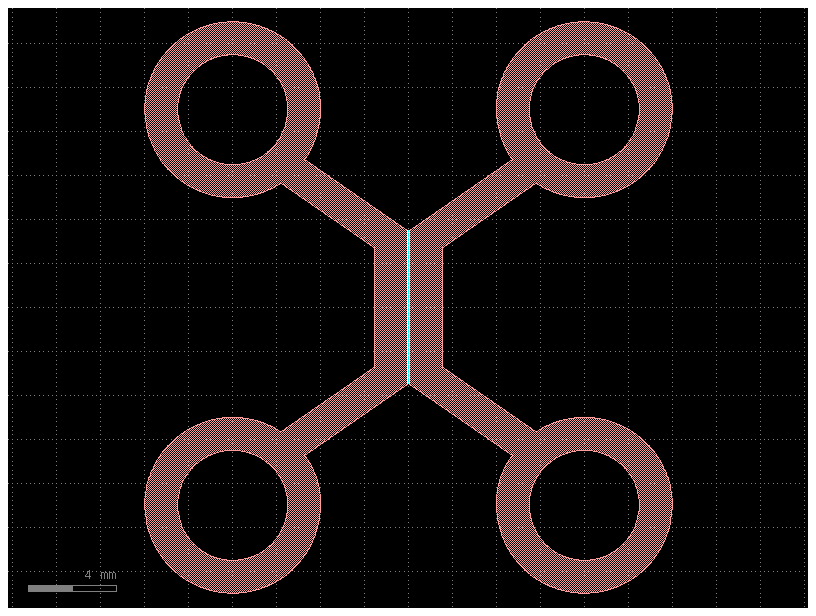

In [6]:
import gdsfactory as gf
from gdsfactory.gpdk import PDK
import numpy as np

PDK.activate()
LAYER_FLUID = (1, 0) 
LAYER_GROOVES = (2,0)

##################################################
################### PARAMETERS ###################
##################################################
channel_V_width = 1500                                                         # channel width
channel_V_height = 7000                                                        # channel length 
gap_between_channels_V = 100                                                   # distance between channels for the microgrooves
#---- 100 micrometer high ----#

channel_S_width = channel_V_width                                              # width of the sloping part of the channel

outer_r = 4000                                                                 # radius of the outer circle (reservoir)
inner_r = outer_r - channel_V_width                                            # radius of the inner circle (reservoir)

offset_x = 8000                                                                # horizontal distance from the middle to the reservoir
offset_y = 9000                                                                # vertical distance from the middle to the reservoir 


groove_width = 130                                                             # length of the grooves + extra space for production
groove_height = 7.5                                                            # groove width  
groove_spacing = 37.5                                                          # distance between the grooves  
#---- 3 micrometer high ----# 
#---- 7,5 micrometer wide ----#
#---- 100 micrometer long ----#                                 

c = gf.Component()


##################################################
################## 4 RESERVOIRS ##################
##################################################
outer = gf.components.circle(radius=outer_r, layer=LAYER_FLUID)                # outer circle
inner = gf.components.circle(radius=inner_r, layer=LAYER_FLUID)                # inner circle 
reservoir = gf.boolean(outer, inner, operation='not', layer=LAYER_FLUID)       # inner circle is taken out of the outer circle 

c.add_ref(reservoir).move((-offset_x, offset_y))                               # upper left
c.add_ref(reservoir).move((offset_x, offset_y))                                # upper right
c.add_ref(reservoir).move((-offset_x, -offset_y))                              # lower left
c.add_ref(reservoir).move((offset_x, -offset_y))                               # lower right


##################################################
############ VERTICAL PARTS CHANNELS #############
##################################################
left_x = -(channel_V_width + gap_between_channels_V/2)                         # placing of the left channel
right_x = gap_between_channels_V/2                                             # placing of the right channel

left_ref = c.add_ref(gf.components.rectangle(                                  # left channel
    size=(channel_V_width, channel_V_height), 
    layer=LAYER_FLUID))    
left_ref.move ((left_x, -channel_V_height/2))                                  # placing the left channel in the correct position

right_ref = c.add_ref(gf.components.rectangle(                                 # right channel
    size=(channel_V_width, channel_V_height), 
    layer=LAYER_FLUID))   
right_ref.move((right_x, -channel_V_height/2))                                 # placing the right channel in the correct position 


##################################################
############# SLOPING PARTS CHANNELS #############
##################################################
def point_on_circle_from_ray(sx, sy, cx, cy, r, angle_deg):                    # connecting the sloping part of the channel to the right spot on the circle
    theta = np.radians(angle_deg)                                              # angle from degrees to radians 
    ux, uy = np.cos(theta), np.sin(theta)                                      # unit vector in direction of the radius

    dx = sx - cx                                                               # vector from start to the centre of the circle
    dy = sy - cy

    b = dx*ux + dy*uy                                                          # quadratic equation: t^2 + 2*b*t + c = 0
    c = dx**2 + dy**2 - r**2

    disc = b**2 - c                                                            # discriminant of the equation 
    if disc < 0:                                                               # negative discriminant is not possible
        raise ValueError("No intersection between radius and circle")

    t1 = -b + np.sqrt(disc)                                                    # two solutions of the equation
    t2 = -b - np.sqrt(disc)

    ts = [t for t in (t1, t2) if t > 0]                                        # only t > 0 (direction of the radius)
    if not ts:
        raise ValueError("No positive intersection")

    t = min(ts)                                                                # pick the closest intersection 

    ex = sx + t*ux                                                             # endpoint of the circle is calculated
    ey = sy + t*uy
    return ex, ey

def add_channel_S(start_x, start_y, end_x, end_y, corner):
    dx = end_x - start_x                                                       # horizontal shift 
    dy = end_y - start_y                                                       # vertical shift 
    length = np.sqrt(dx**2 + dy**2)                                            # length of the sloping part 
    angle = np.degrees(np.arctan2(dy, dx))                                     # rotationangle of the sloping part

    channel_S = gf.components.rectangle(                                       # sloping part of the channels without centering
        size=(length, channel_S_width),
        layer=LAYER_FLUID,
        centered=False
    )

    ref = c.add_ref(channel_S)                                                 # adding channels to the component

    if corner == "LL":      # lower-left corner                                # picking the right corner as the starting point
        ref.move((0, 0))
    elif corner == "UL":    # upper-left corner
        ref.move((0, -channel_S_width))

    ref.rotate(angle)                                                          # rotating the channel to the right angle 
    ref.move((start_x, start_y))                                               # moving the channel to the right spot

# UPPER FLEFT #
sx, sy = left_x + channel_V_width, channel_V_height/2                          # determining the starting point 
cx, cy = -offset_x, offset_y                                                   # middle of the circle
angle_S = np.degrees(np.arctan2(cy - sy, cx - sx))                             # angle of the sloping part of the channel
ex, ey = point_on_circle_from_ray(sx, sy, cx, cy, inner_r, angle_S)            # determining the endpoint on the circle
add_channel_S(sx, sy, ex, ey, "LL")                                            # adding the right corner to the sloping part

# UPPER RIGHT #
sx, sy = right_x, channel_V_height/2
cx, cy = offset_x, offset_y
angle_S = np.degrees(np.arctan2(cy - sy, cx - sx))
ex, ey = point_on_circle_from_ray(sx, sy, cx, cy, inner_r, angle_S)
add_channel_S(sx, sy, ex, ey, "UL")   

# LOWER LEFT #
sx, sy = left_x + channel_V_width, -channel_V_height/2
cx, cy = -offset_x, -offset_y
angle_S = np.degrees(np.arctan2(cy - sy, cx - sx))
ex, ey = point_on_circle_from_ray(sx, sy, cx, cy, inner_r, angle_S)
add_channel_S(sx, sy, ex, ey, "UL")   

# LOWER RIGHT #
sx, sy = right_x, -channel_V_height/2
cx, cy = offset_x, -offset_y
angle_S = np.degrees(np.arctan2(cy - sy, cx - sx))
ex, ey = point_on_circle_from_ray(sx, sy, cx, cy, inner_r, angle_S)
add_channel_S(sx, sy, ex, ey, "LL")   


##################################################
################## MICROGROOVES ##################
##################################################
y = channel_V_height / 2                                                        # going over the whole vertical part of the channel with a while loop
while y > -channel_V_height/2: 
    groove = gf.components.rectangle(
        size=(groove_width, groove_height), 
        layer=LAYER_GROOVES)                                                    # 1 horizontal stripe
    ref = c.add_ref(groove)                                                     # adding grooves to the component 
    ref.move((-groove_width/2, y))                                              # adding the grooves so they overlap with the channels
    y -= groove_spacing                                                         # go to the next groove until the end


#################################################
#################### CLEANUP ####################
#################################################
layers = c.layers 
c_clean = gf.Component()

for layer in layers: 
    result = gf.boolean(c, c, operation='or', layer=layer)
    c_clean.add_ref(result)

c = c_clean


#################################################
##################### PLOT ######################
#################################################
c.plot()

Paper 2 with dendrites (75x10x3 micrometer)

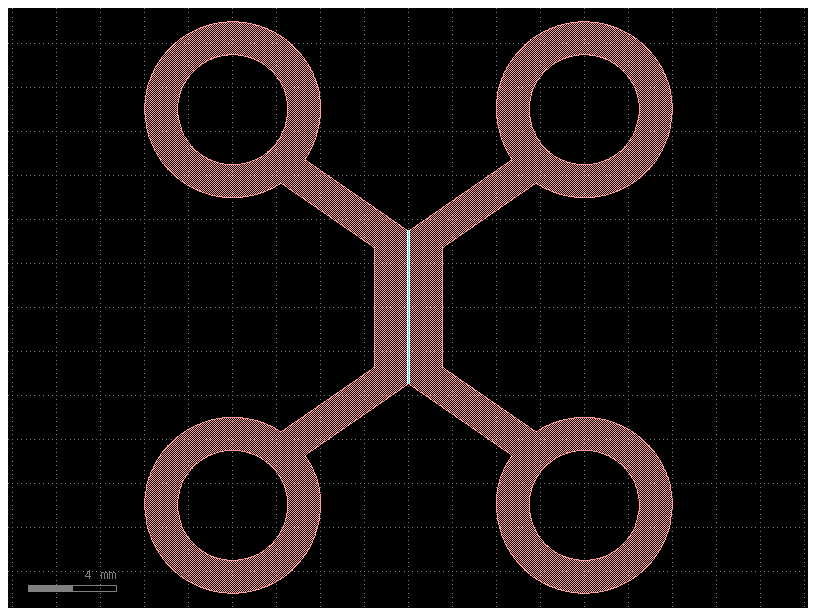

In [7]:
import gdsfactory as gf
from gdsfactory.gpdk import PDK
import numpy as np

PDK.activate()
LAYER_FLUID = (1, 0) 
LAYER_GROOVES = (2,0)

##################################################
################### PARAMETERS ###################
##################################################
channel_V_width = 1500                                                         # channel width
channel_V_height = 7000                                                        # channel length 
gap_between_channels_V = 75                                                    # distance between channels for the microgrooves
#---- 100 micrometer high ----#

channel_S_width = channel_V_width                                              # width of the sloping part of the channel

outer_r = 4000                                                                 # radius of the outer circle (reservoir)
inner_r = outer_r - channel_V_width                                            # radius of the inner circle (reservoir)

offset_x = 8000                                                                # horizontal distance from the middle to the reservoir
offset_y = 9000                                                                # vertical distance from the middle to the reservoir 


groove_width = 100                                                             # length of the grooves + extra space for production
groove_height = 10                                                             # groove width  
groove_spacing = 37.5                                                          # distance between the grooves  
#---- 3 micrometer high ----# 
#---- 10 micrometer wide ----#
#---- 75 micrometer long ----#                                 

c = gf.Component()


##################################################
################## 4 RESERVOIRS ##################
##################################################
outer = gf.components.circle(radius=outer_r, layer=LAYER_FLUID)                # outer circle
inner = gf.components.circle(radius=inner_r, layer=LAYER_FLUID)                # inner circle 
reservoir = gf.boolean(outer, inner, operation='not', layer=LAYER_FLUID)       # inner circle is taken out of the outer circle 

c.add_ref(reservoir).move((-offset_x, offset_y))                               # upper left
c.add_ref(reservoir).move((offset_x, offset_y))                                # upper right
c.add_ref(reservoir).move((-offset_x, -offset_y))                              # lower left
c.add_ref(reservoir).move((offset_x, -offset_y))                               # lower right


##################################################
############ VERTICAL PARTS CHANNELS #############
##################################################
left_x = -(channel_V_width + gap_between_channels_V/2)                         # placing of the left channel
right_x = gap_between_channels_V/2                                             # placing of the right channel

left_ref = c.add_ref(gf.components.rectangle(                                  # left channel
    size=(channel_V_width, channel_V_height), 
    layer=LAYER_FLUID))    
left_ref.move ((left_x, -channel_V_height/2))                                  # placing the left channel in the correct position

right_ref = c.add_ref(gf.components.rectangle(                                 # right channel
    size=(channel_V_width, channel_V_height), 
    layer=LAYER_FLUID))   
right_ref.move((right_x, -channel_V_height/2))                                 # placing the right channel in the correct position


##################################################
############# SLOPING PARTS CHANNELS #############
##################################################
def point_on_circle_from_ray(sx, sy, cx, cy, r, angle_deg):                    # connecting the sloping part of the channel to the right spot on the circle
    theta = np.radians(angle_deg)                                              # angle from degrees to radians 
    ux, uy = np.cos(theta), np.sin(theta)                                      # unit vector in direction of the radius

    dx = sx - cx                                                               # vector from start to the centre of the circle
    dy = sy - cy

    b = dx*ux + dy*uy                                                          # quadratic equation: t^2 + 2*b*t + c = 0
    c = dx**2 + dy**2 - r**2

    disc = b**2 - c                                                            # discriminant of the equation 
    if disc < 0:                                                               # negative discriminant is not possible
        raise ValueError("No intersection between radius and circle")

    t1 = -b + np.sqrt(disc)                                                    # two solutions of the equation
    t2 = -b - np.sqrt(disc)

    ts = [t for t in (t1, t2) if t > 0]                                        # only t > 0 (direction of the radius)
    if not ts:
        raise ValueError("No positive intersection")

    t = min(ts)                                                                # pick the closest intersection 

    ex = sx + t*ux                                                             # endpoint of the circle is calculated
    ey = sy + t*uy
    return ex, ey

def add_channel_S(start_x, start_y, end_x, end_y, corner):
    dx = end_x - start_x                                                       # horizontal shift 
    dy = end_y - start_y                                                       # vertical shift 
    length = np.sqrt(dx**2 + dy**2)                                            # length of the sloping part 
    angle = np.degrees(np.arctan2(dy, dx))                                     # rotationangle of the sloping part

    channel_S = gf.components.rectangle(                                       # sloping part of the channels without centering
        size=(length, channel_S_width),
        layer=LAYER_FLUID,
        centered=False
    )

    ref = c.add_ref(channel_S)                                                 # adding channels to the component

    if corner == "LL":      # lower-left corner                                # picking the right corner as the starting point
        ref.move((0, 0))
    elif corner == "UL":    # upper-left corner
        ref.move((0, -channel_S_width))

    ref.rotate(angle)                                                          # rotating the channel to the right angle 
    ref.move((start_x, start_y))                                               # moving the channel to the right spot

# UPPER FLEFT #
sx, sy = left_x + channel_V_width, channel_V_height/2                          # determining the starting point 
cx, cy = -offset_x, offset_y                                                   # middle of the circle
angle_S = np.degrees(np.arctan2(cy - sy, cx - sx))                             # angle of the sloping part of the channel
ex, ey = point_on_circle_from_ray(sx, sy, cx, cy, inner_r, angle_S)            # determining the endpoint on the circle
add_channel_S(sx, sy, ex, ey, "LL")                                            # adding the right corner to the sloping part

# UPPER RIGHT #
sx, sy = right_x, channel_V_height/2
cx, cy = offset_x, offset_y
angle_S = np.degrees(np.arctan2(cy - sy, cx - sx))
ex, ey = point_on_circle_from_ray(sx, sy, cx, cy, inner_r, angle_S)
add_channel_S(sx, sy, ex, ey, "UL")   

# LOWER LEFT #
sx, sy = left_x + channel_V_width, -channel_V_height/2
cx, cy = -offset_x, -offset_y
angle_S = np.degrees(np.arctan2(cy - sy, cx - sx))
ex, ey = point_on_circle_from_ray(sx, sy, cx, cy, inner_r, angle_S)
add_channel_S(sx, sy, ex, ey, "UL")   

# LOWER RIGHT #
sx, sy = right_x, -channel_V_height/2
cx, cy = offset_x, -offset_y
angle_S = np.degrees(np.arctan2(cy - sy, cx - sx))
ex, ey = point_on_circle_from_ray(sx, sy, cx, cy, inner_r, angle_S)
add_channel_S(sx, sy, ex, ey, "LL")   


##################################################
################## MICROGROOVES ##################
##################################################
y = channel_V_height / 2                                                        # going over the whole vertical part of the channel with a while loop
while y > -channel_V_height/2: 
    groove = gf.components.rectangle(
        size=(groove_width, groove_height), 
        layer=LAYER_GROOVES)                                                    # 1 horizontal stripe
    ref = c.add_ref(groove)                                                     # adding grooves to the component 
    ref.move((-groove_width/2, y))                                              # adding the grooves so they overlap with the channels 
    y -= groove_spacing                                                         # go to the next groove until the end


#################################################
#################### CLEANUP ####################
#################################################
layers = c.layers 
c_clean = gf.Component()

for layer in layers: 
    result = gf.boolean(c, c, operation='or', layer=layer)
    c_clean.add_ref(result)

c = c_clean


#################################################
##################### PLOT ######################
#################################################
c.plot()